# Day 5.1: The Problem with Imbalanced Datasets

## Table of Contents
1. [Introduction](#introduction)
2. [What is an Imbalanced Dataset?](#what-is-an-imbalanced-dataset)
3. [Why is Imbalance a Problem?](#why-is-imbalance-a-problem)
   - [Misleading Accuracy](#misleading-accuracy)
   - [Model Bias](#model-bias)
   - [Poor Minority Class Detection](#poor-minority-class-detection)
4. [Identifying Imbalance](#identifying-imbalance)
5. [Summary](#summary)

## 1. Introduction

In machine learning classification tasks, we often assume that our target classes are distributed fairly evenly. However, many real-world problems involve datasets where one class (the **majority class**) significantly outnumbers the other (the **minority class**). This situation is known as **class imbalance**, and it presents unique challenges that can significantly impact model performance.

Today, we'll explore why imbalanced datasets are problematic and how to identify them in your data.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## What is an Imbalanced Dataset?

An imbalanced dataset is one where the classes are not represented equally. One class (the **majority class**) has significantly more samples than the other(s) (the **minority class**). This imbalance can range from slight (e.g., 60:40 ratio) to extreme (e.g., 99.9:0.1 ratio).

### Real-World Examples

Let's look at some common real-world scenarios where imbalanced datasets naturally occur:

1. **Fraud Detection**: Typically, less than 1% of credit card transactions are fraudulent.
2. **Medical Diagnosis**: Rare diseases might affect only a small percentage of the population.
3. **Manufacturing Quality Control**: Defective parts are usually a small minority of production.
4. **Network Intrusion Detection**: Normal network traffic vastly outnumbers malicious attacks.
5. **Customer Churn Prediction**: Most customers do not churn in a given period.
6. **Ad Click-Through Rate Prediction**: Users click on only a small fraction of displayed ads.

Let's visualize what an imbalanced dataset looks like:

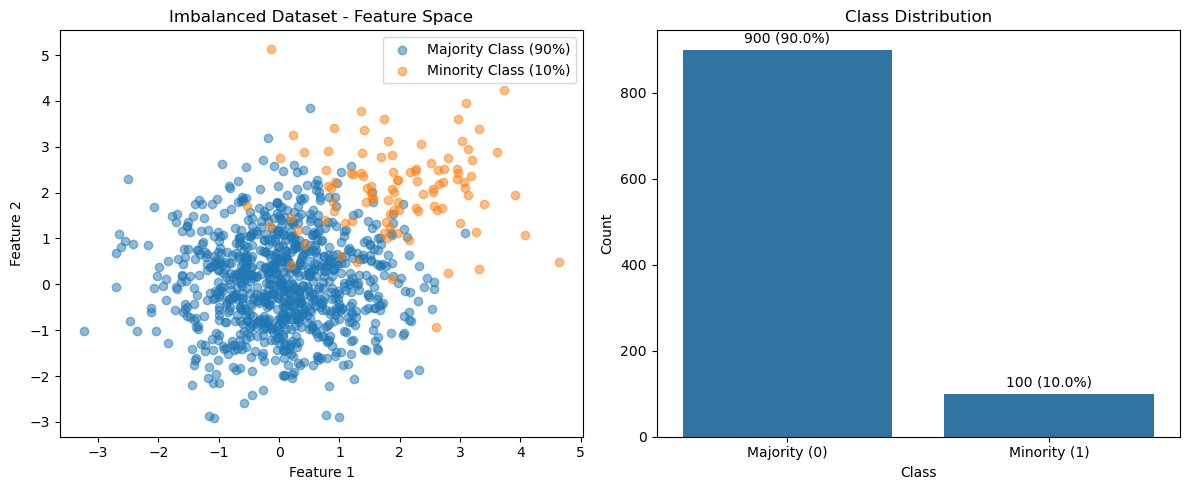

In [3]:
# Generate a synthetic imbalanced dataset for visualization
np.random.seed(42)
majority_class = np.random.normal(loc=0, scale=1, size=(900, 2))
minority_class = np.random.normal(loc=2, scale=1, size=(100, 2))

X = np.vstack([majority_class, minority_class])
y = np.hstack([np.zeros(900), np.ones(100)])

# Create a DataFrame
imbalanced_df = pd.DataFrame({
    'Feature_1': X[:, 0],
    'Feature_2': X[:, 1],
    'Class': y
})

# Visualize the class distribution
plt.figure(figsize=(12, 5))

# Scatter plot of features
plt.subplot(1, 2, 1)
plt.scatter(majority_class[:, 0], majority_class[:, 1], alpha=0.5, label='Majority Class (90%)')
plt.scatter(minority_class[:, 0], minority_class[:, 1], alpha=0.5, label='Minority Class (10%)')
plt.title('Imbalanced Dataset - Feature Space')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Bar chart of class distribution
plt.subplot(1, 2, 2)
sns.countplot(x='Class', data=imbalanced_df)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Majority (0)', 'Minority (1)'])

for i, count in enumerate(imbalanced_df['Class'].value_counts()):
    plt.text(i, count + 10, f'{count} ({count/len(imbalanced_df)*100:.1f}%)', 
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Why is Imbalance a Problem?

Class imbalance creates several significant challenges for machine learning models:

### 1. Misleading Accuracy

With imbalanced data, accuracy becomes a misleading metric. A model can achieve high accuracy by simply predicting the majority class for all instances.

**Example**: In a fraud detection scenario where only 1% of transactions are fraudulent, a model that simply predicts "not fraud" for every transaction would achieve 99% accuracy but would be completely useless for identifying fraud cases.

Let's demonstrate this with our synthetic dataset:

In [4]:
# Example: Misleading accuracy with imbalanced data
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create a dummy classifier that always predicts the majority class
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X, y)
y_pred = dummy_clf.predict(X)

# Calculate accuracy
accuracy = accuracy_score(y, y_pred)

print(f"Accuracy of always predicting majority class: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Majority', 'Minority']))

Accuracy of always predicting majority class: 0.9000

Classification Report:
              precision    recall  f1-score   support

    Majority       0.90      1.00      0.95       900
    Minority       0.00      0.00      0.00       100

    accuracy                           0.90      1000
   macro avg       0.45      0.50      0.47      1000
weighted avg       0.81      0.90      0.85      1000



C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In this example, by simply predicting the majority class for every instance, we achieve 90% accuracy! However, the classifier completely fails to identify the minority class (0% recall). This is particularly problematic when the minority class is often the class of interest.

Let's visualize the decision boundary of this naive classifier:

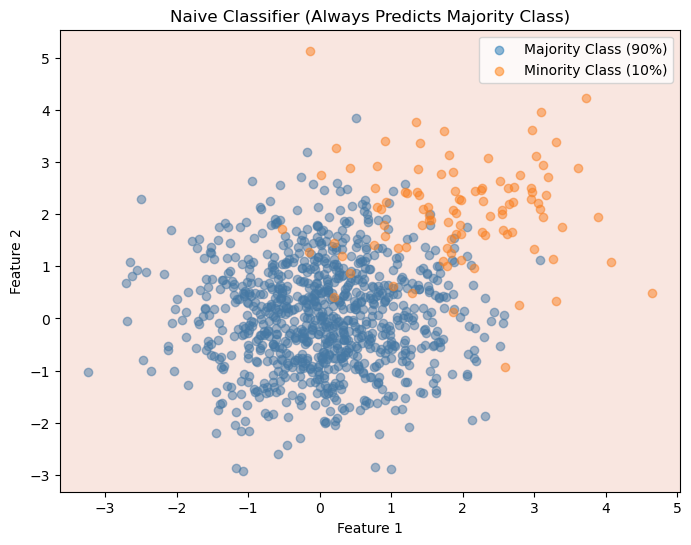

In [5]:
# Visualize the decision boundary of the naive majority-class classifier
plt.figure(figsize=(8, 6))
plt.scatter(majority_class[:, 0], majority_class[:, 1], alpha=0.5, label='Majority Class (90%)')
plt.scatter(minority_class[:, 0], minority_class[:, 1], alpha=0.5, label='Minority Class (10%)')

# Shade the entire space as the majority class
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = np.zeros(xx.shape)  # Always predict majority class (0)
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdBu)

plt.title('Naive Classifier (Always Predicts Majority Class)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

### 2. Model Bias

Most machine learning algorithms are designed to maximize overall accuracy, which inherently biases them toward the majority class. This leads to poor performance on the minority class, which is often the class of interest.

Let's train a basic logistic regression model on our imbalanced dataset:

In [6]:
# Example: Model bias with imbalanced data
from sklearn.linear_model import LogisticRegression

# Create and train a logistic regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X, y)
y_pred_log = log_reg.predict(X)

# Calculate metrics
print("Logistic Regression on imbalanced data:")
print(classification_report(y, y_pred_log, target_names=['Majority', 'Minority']))

Logistic Regression on imbalanced data:
              precision    recall  f1-score   support

    Majority       0.97      0.99      0.98       900
    Minority       0.88      0.74      0.80       100

    accuracy                           0.96      1000
   macro avg       0.93      0.86      0.89      1000
weighted avg       0.96      0.96      0.96      1000



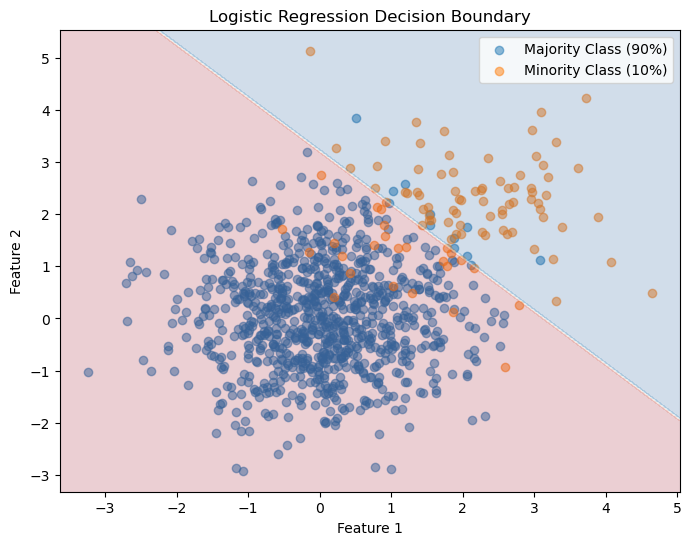

In [7]:
# Visualize the decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(majority_class[:, 0], majority_class[:, 1], alpha=0.5, label='Majority Class (90%)')
plt.scatter(minority_class[:, 0], minority_class[:, 1], alpha=0.5, label='Minority Class (10%)')

# Plot decision boundary
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdBu)

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

The model tends to favor the majority class, often misclassifying minority class instances. This is especially problematic because the minority class is typically the class of interest (e.g., fraud detection, disease diagnosis).

### 3. Poor Minority Class Detection

With limited exposure to minority class examples during training, models often learn very little about the characteristics of this class. This leads to poor generalization and detection capabilities.

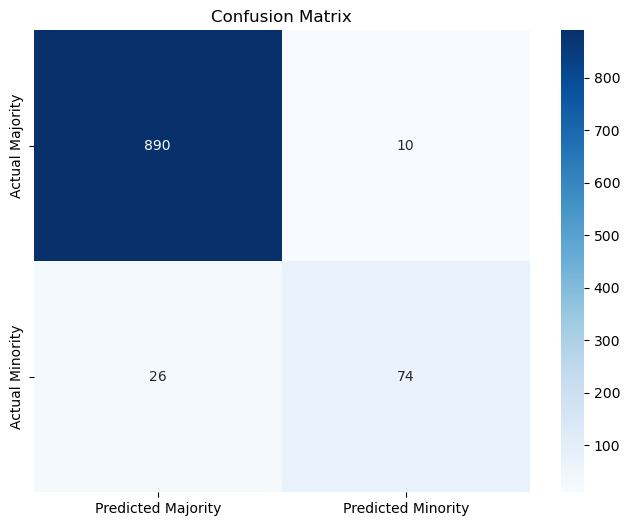

In [8]:
# Let's visualize where the model makes mistakes
from sklearn.metrics import confusion_matrix

# Get predictions
y_pred_log = log_reg.predict(X)

# Create confusion matrix
cm = confusion_matrix(y, y_pred_log)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Majority', 'Predicted Minority'],
            yticklabels=['Actual Majority', 'Actual Minority'])
plt.title('Confusion Matrix')
plt.show()

In [9]:
# Calculate error rates for each class
majority_error = cm[0, 1] / sum(cm[0])
minority_error = cm[1, 0] / sum(cm[1])

print(f"Error rate for majority class: {majority_error:.4f}")
print(f"Error rate for minority class: {minority_error:.4f}")
print(f"Minority class error is {minority_error/majority_error:.1f}x higher than majority class error")

Error rate for majority class: 0.0111
Error rate for minority class: 0.2600
Minority class error is 23.4x higher than majority class error


## Identifying Imbalance

Before addressing imbalance, we need to identify it in our dataset. Let's look at some practical ways to do this:

In [35]:
# Function to check for imbalance in a dataset
def check_imbalance(y, verbose=True):
    """
    Check for class imbalance in a target variable.
    
    Parameters:
    y (array-like): Target variable
    verbose (bool): Whether to print detailed information
    
    Returns:
    float: Imbalance ratio (majority/minority)
    """
    # Convert to pandas Series for easier analysis
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    
    # Get class distribution
    class_counts = y.value_counts()
    class_proportions = y.value_counts(normalize=True)
    
    # Calculate imbalance ratio (majority/minority)
    imbalance_ratio = class_counts.max() / class_counts.min()
    
    if verbose:
        print("Class distribution:")
        for cls, count in class_counts.items():
            print(f"Class {cls}: {count} samples ({class_proportions[cls]:.2%})")
        
        print(f"\nImbalance ratio (majority/minority): {imbalance_ratio:.2f}")
        
        # Provide interpretation
        if imbalance_ratio < 1.5:
            print("Assessment: Dataset is relatively balanced")
        elif imbalance_ratio < 3:
            print("Assessment: Dataset has mild imbalance")
        elif imbalance_ratio < 10:
            print("Assessment: Dataset has moderate imbalance")
        else:
            print("Assessment: Dataset has severe imbalance")
    
    return imbalance_ratio

# Example: Checking imbalance in our synthetic dataset
check_imbalance(y)

Class distribution:
Class 0.0: 900 samples (90.00%)
Class 1.0: 100 samples (10.00%)

Imbalance ratio (majority/minority): 9.00
Assessment: Dataset has moderate imbalance


9.0

### Visualizing Imbalance

Visualizing class distribution is a simple yet effective way to identify imbalance:

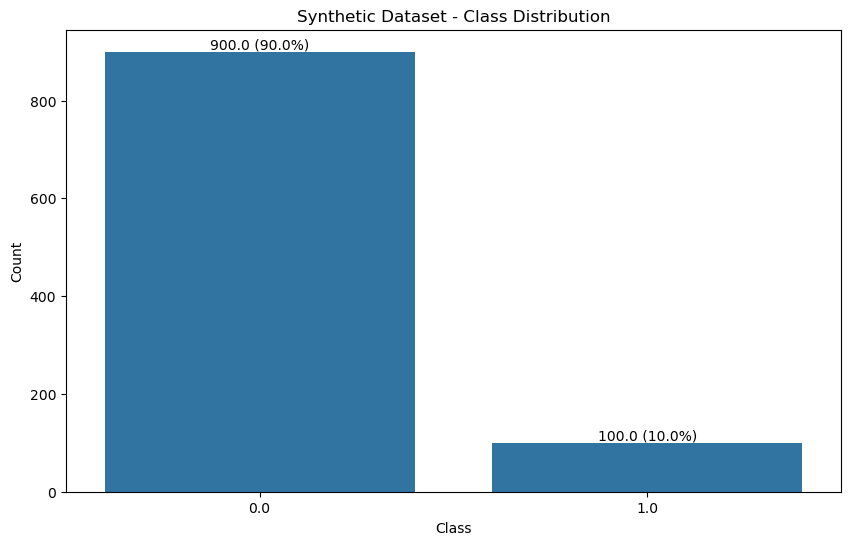

In [33]:
# Visualize class distribution
def plot_class_distribution(y, title="Class Distribution"):
    """
    Plot the distribution of classes in a target variable.
    
    Parameters:
    y (array-like): Target variable
    title (str): Plot title
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    
    plt.figure(figsize=(10, 6))
    
    # Create a count plot
    ax = sns.countplot(x=y)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    
    # Add count and percentage labels
    total = len(y)
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2.,
                height + 5,
                f'{height} ({height/total:.1%})',
                ha="center")
    
    plt.show()

# Example: Visualizing class distribution
plot_class_distribution(y, "Synthetic Dataset - Class Distribution")

### Real-World Examples

Let's look at some real dataset examples using popular classification datasets:

In [30]:
# Load some real-world datasets
from sklearn.datasets import load_breast_cancer, fetch_openml

# Breast Cancer dataset
cancer = load_breast_cancer()
cancer_y = pd.Series(cancer.target, name="Diagnosis")
print("Breast Cancer Wisconsin Dataset:")
check_imbalance(cancer_y)

Breast Cancer Wisconsin Dataset:
Class distribution:
Class 1: 357 samples (62.74%)
Class 0: 212 samples (37.26%)

Imbalance ratio (majority/minority): 1.68
Assessment: Dataset has mild imbalance


1.6839622641509433

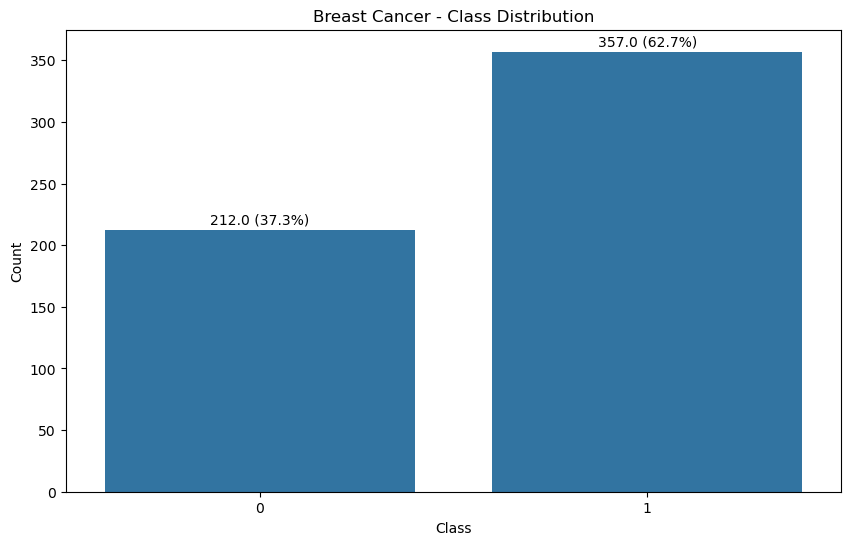

In [31]:
plot_class_distribution(cancer_y, "Breast Cancer - Class Distribution")

## Knowledge Check

Let's test your understanding of imbalanced datasets:

1. **True or False**: A dataset with a 70:30 class ratio would typically be considered severely imbalanced.

`Answer`
False. A 70:30 ratio represents mild imbalance. Severe imbalance is typically >10:1 ratio.

2. **Multiple Choice**: What is the main issue with using accuracy to evaluate models on imbalanced data?
   a) It's too complex to calculate
   b) It can be misleadingly high even when the model performs poorly on the minority class
   c) It only works for binary classification
   d) It cannot be used with neural networks

`Answer`
b) It can be misleadingly high even when the model performs poorly on the minority class.

3. **Application**: For a credit card fraud detection system where only 0.5% of transactions are fraudulent, what would be the accuracy of a naive classifier that always predicts "not fraud"?

`Answer`
The accuracy would be 99.5%, but the recall for fraud (the class of interest) would be 0%.

## Summary

In this section, we've explored the challenge of imbalanced datasets in machine learning:

- **Imbalanced datasets** occur when one class significantly outnumbers the other(s)
- Common examples include fraud detection, disease diagnosis, and defect detection
- Imbalance creates several problems:
  - **Misleading accuracy**: High accuracy can be achieved by simply predicting the majority class
  - **Model bias**: Algorithms naturally favor the majority class
  - **Poor minority class detection**: Models learn very little about the minority class

- We can identify imbalance by:
  - Calculating class proportions using `value_counts(normalize=True)`
  - Visualizing class distribution
  - Computing the imbalance ratio (majority/minority)

In the next section, we'll explore techniques for effectively handling imbalanced datasets, including resampling methods and algorithmic approaches.